<a href="https://colab.research.google.com/github/delacroissant/Sudoku-solver-with-Grover-s-algorithm/blob/main/Grover_sudoku.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pennylane

In [3]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

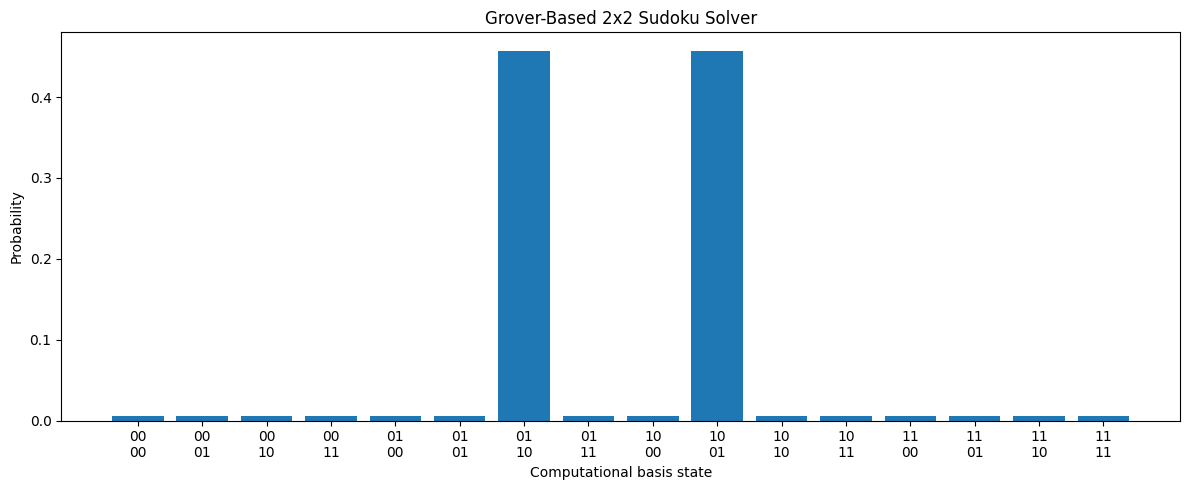


Circuit:



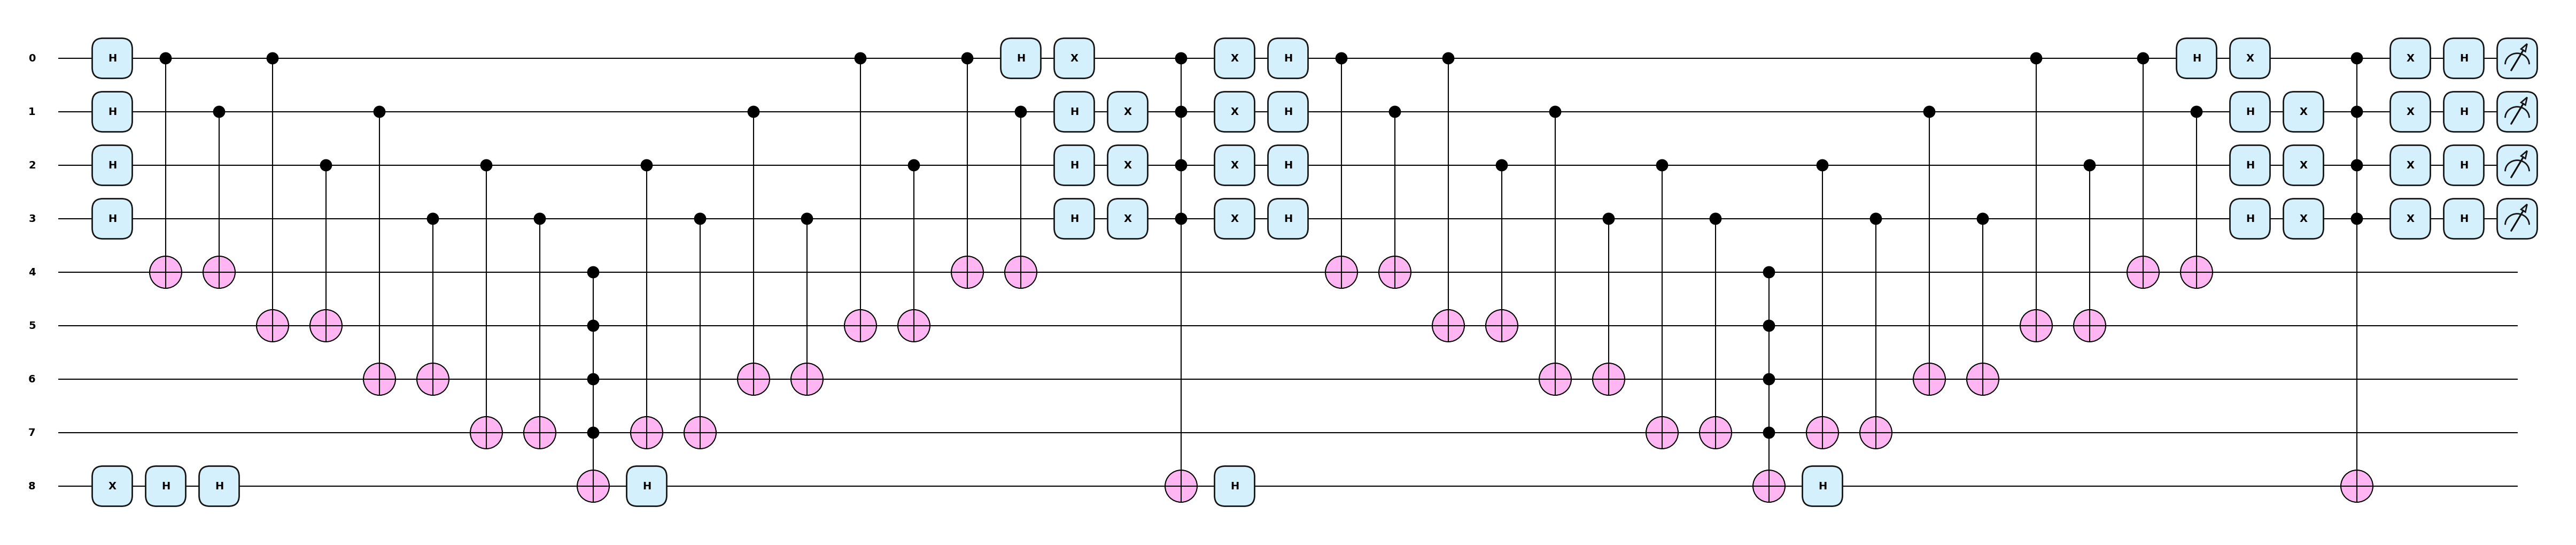

In [7]:
query_wires = [0, 1, 2, 3]
aux_wires = [4,5,6,7]
aux_wire = [8]
total_wires = query_wires + aux_wires + aux_wire


dev = qml.device("default.qubit",wires=total_wires)


def sudoku_oracle():
    #Imposing the constraints for a 2x2 Sudoku
    #A != B
    qml.CNOT([0,4])
    qml.CNOT([1,4])

    #A!= C
    qml.CNOT([0,5])
    qml.CNOT([2,5])

    #B!= D
    qml.CNOT([1,6])
    qml.CNOT([3,6])

    #C!= D
    qml.CNOT([2,7])
    qml.CNOT([3,7])

    qml.H(aux_wire)

    qml.MultiControlledX(aux_wires + aux_wire,control_values=[1]*len(aux_wires))

    qml.H(aux_wire)

    #Undoing the constraints for a 2x2 Sudoku (uncomputing)
    qml.CNOT([2,7])
    qml.CNOT([3,7])

    qml.CNOT([1,6])
    qml.CNOT([3,6])

    qml.CNOT([0,5])
    qml.CNOT([2,5])

    qml.CNOT([0,4])
    qml.CNOT([1,4])




def diffusion(wires):

    for w in wires:
        qml.H(wires=w)

    for w in wires:
        qml.X(wires=w)

    qml.MultiControlledX(wires + aux_wire,control_values=[1]*len(wires))

    for w in wires:
        qml.X(wires=w)

    for w in wires:
        qml.H(wires=w)



grover_iter = 2


@qml.qnode(dev)
def grover_sudoku():

    for wire in query_wires:
        qml.H(wire)


    qml.X(aux_wire)
    qml.H(aux_wire)


    for _ in range(grover_iter):

        sudoku_oracle()

        diffusion(query_wires)


    return qml.probs(wires=query_wires)


probs = grover_sudoku()

labels = [format(i, "04b") for i in range(16)]
labels_2rows = [s[:2] + "\n" + s[2:] for s in labels]


plt.figure(figsize=(12, 5))

plt.bar(labels_2rows, probs)

plt.xlabel("Computational basis state")
plt.ylabel("Probability")
plt.title("Grover-Based 2x2 Sudoku Solver")



plt.tight_layout()

plt.show()


print("\nCircuit:\n")

fig, ax = qml.draw_mpl(grover_sudoku, style='pennylane')()
fig.show()